1.1

In [41]:
import numpy as np

values = np.linspace(0, 20, 100)

print("Mean =", np.mean(values))
print("Median =", np.median(values))
print("Standard Deviation =", np.std(values))
print("Variance =", np.var(values))

Mean = 10.0
Median = 10.0
Standard Deviation = 5.831529302570125
Variance = 34.00673400673401


1.2


In [42]:
import numpy as np

arr = np.arange(1, 37)
print(arr)
print("Original shape:", arr.shape)

matrix = arr.reshape(4, 9)
print(matrix)
print("Reshaped shape:", matrix.shape)

flat_arr = matrix.flatten()
print(flat_arr)
print("Flattened shape:", flat_arr.shape)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
Original shape: (36,)
[[ 1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18]
 [19 20 21 22 23 24 25 26 27]
 [28 29 30 31 32 33 34 35 36]]
Reshaped shape: (4, 9)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36]
Flattened shape: (36,)


2.1


In [43]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [45]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


2.2

In [46]:
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Percentage Missing": missing_percentage
})

print(missing_df[missing_df["Missing Count"] > 0])

             Missing Count  Percentage Missing
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [47]:
df["age"] = df["age"].fillna(
    df.groupby("pclass")["age"].transform("median")
)

df["embarked"] = df["embarked"].fillna(
    df["embarked"].mode()[0]
)
if "deck" in df.columns:
    df = df.drop(columns=["deck"])

In [48]:
print("Missing values in age:", df["age"].isnull().sum())
print("Missing values in embarked:", df["embarked"].isnull().sum())

Missing values in age: 0
Missing values in embarked: 0


3.1

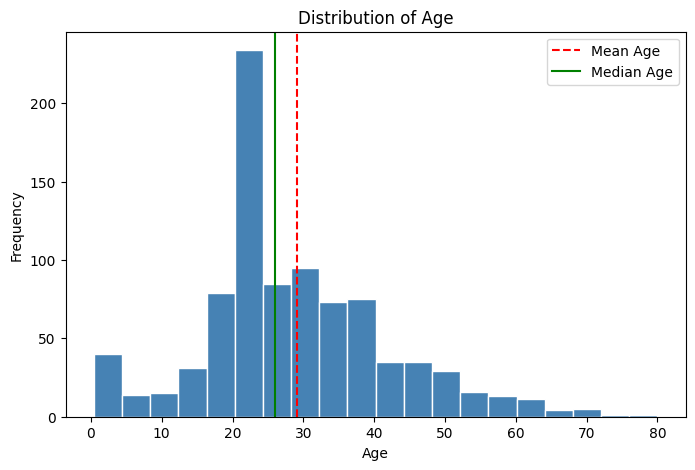

In [49]:
import matplotlib.pyplot as plt

mean_age = df["age"].mean()
median_age = df["age"].median()

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, color="steelblue", edgecolor="white")

plt.axvline(mean_age, color="red", linestyle="--", label="Mean Age")
plt.axvline(median_age, color="green", label="Median Age")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()

plt.show()

3.2

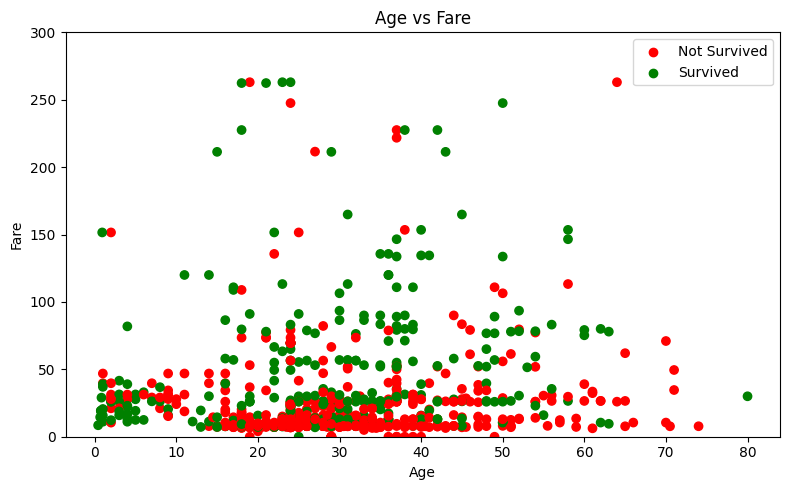

In [50]:
import matplotlib.pyplot as plt

colors = df["survived"].map({0: "red", 1: "green"})

plt.figure(figsize=(8,5))

plt.scatter(df["age"], df["fare"], c=colors)

plt.ylim(0, 300)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.scatter([], [], color="red", label="Not Survived")
plt.scatter([], [], color="green", label="Survived")

plt.legend()

plt.tight_layout()
plt.show()

4.1

In [51]:
!pip -q install kagglehub

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ashydv/advertising-dataset")

df = pd.read_csv(os.path.join(path, "advertising.csv"))

print(df.head())

Using Colab cache for faster access to the 'advertising-dataset' dataset.
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [52]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

Shape: (200, 4)

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Summary Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


TV advertising has the largest spread among all variables, while Radio and Newspaper are spread over a smaller range. Sales values also vary across observations, showing differences in product performance.

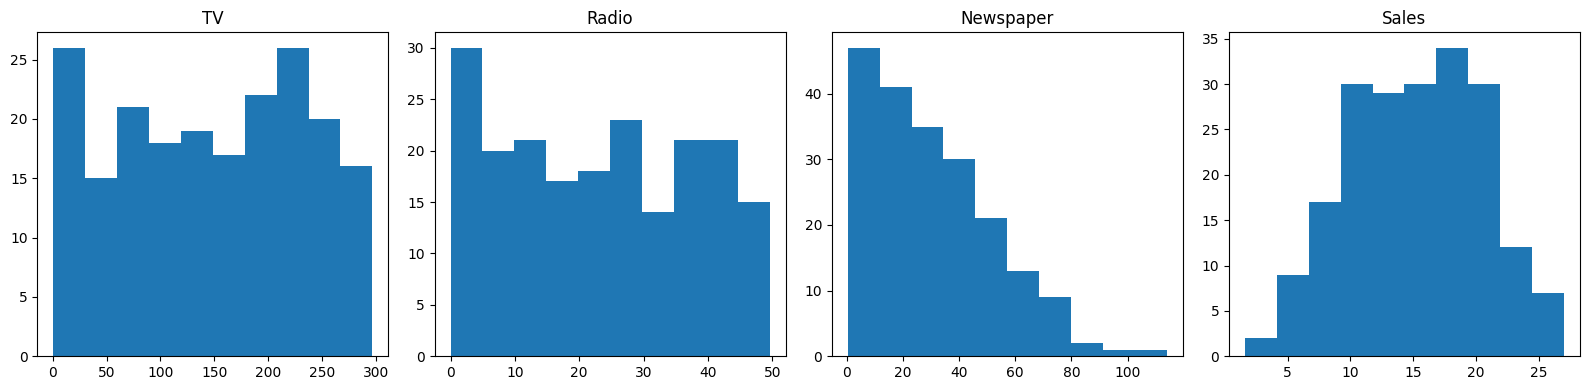

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].hist(df["TV"])
axes[0].set_title("TV")

axes[1].hist(df["Radio"])
axes[1].set_title("Radio")

axes[2].hist(df["Newspaper"])
axes[2].set_title("Newspaper")

axes[3].hist(df["Sales"])
axes[3].set_title("Sales")

plt.tight_layout()
plt.show()

The Newspaper variable seems to have a few unusually high values compared to the rest of the data. The other variables appear more evenly distributed with fewer noticeable outliers.



4.2

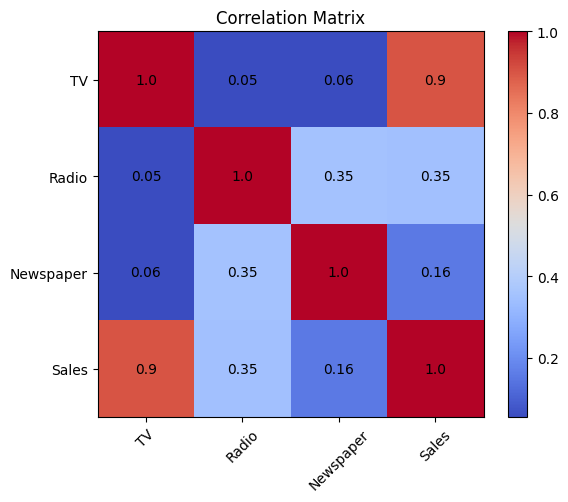

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


In [54]:
import numpy as np
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i,
                 round(corr_matrix.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print(corr_matrix)

Sales is most strongly correlated with TV. TV and Radio show a weak correlation with each other, indicating that spending on one channel does not predict spending on the other to a great extent.

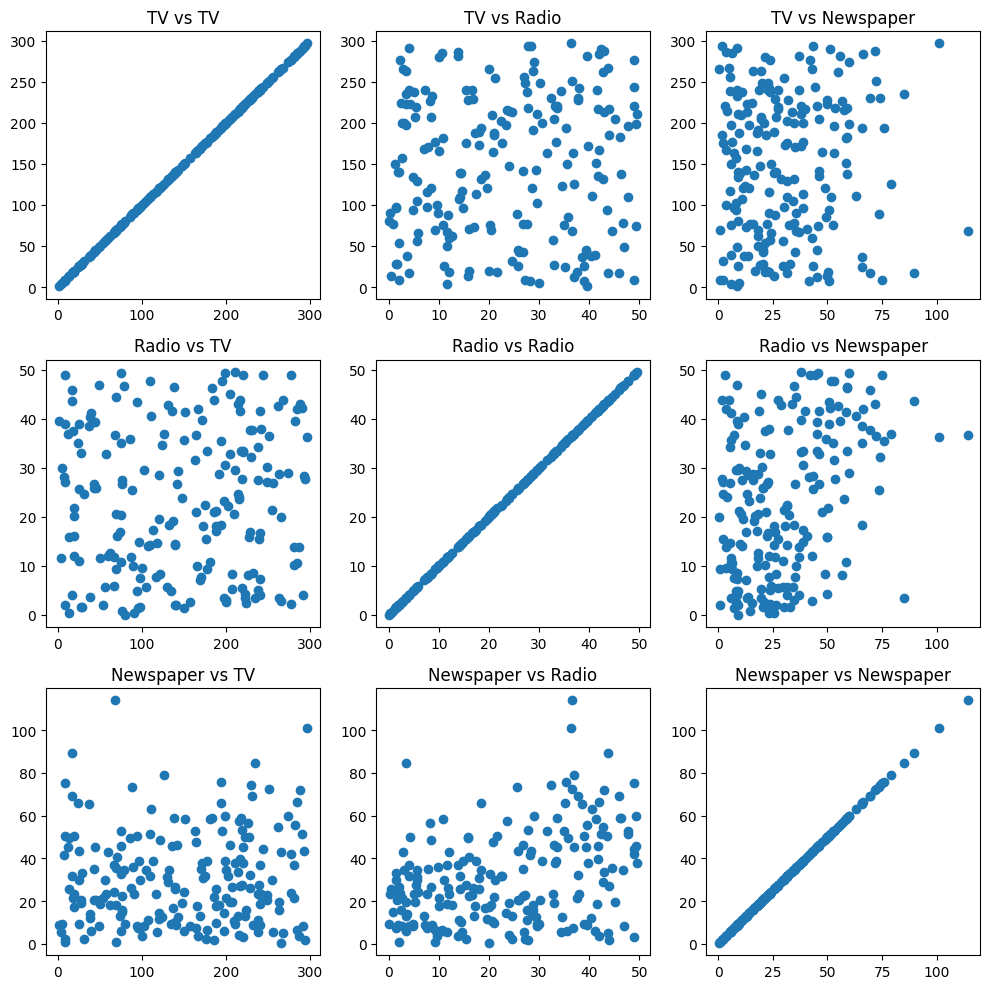

In [55]:
import matplotlib.pyplot as plt

cols = ["TV", "Radio", "Newspaper"]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i in range(3):
    for j in range(3):
        axes[i, j].scatter(df[cols[j]], df[cols[i]])
        axes[i, j].set_title(f"{cols[i]} vs {cols[j]}")

plt.tight_layout()
plt.show()

5.1

In [56]:
import numpy as np



X = df["TV"].values
y = df["Sales"].values


X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]



m = np.sum((X_train - np.mean(X_train)) * (y_train - np.mean(y_train))) / \
    np.sum((X_train - np.mean(X_train)) ** 2)



b = np.mean(y_train) - m * np.mean(X_train)

print("Slope (m):", m)
print("Intercept (b):", b)



y_pred = m * X_test + b



mse = np.mean((y_test - y_pred) ** 2)

print("MSE:", mse)

Slope (m): 0.05572601895005874
Intercept (b): 6.993686960994353
MSE: 5.459799471482253


5.2

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["TV"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.0554829439314632
Intercept: 7.007108428241848


The coefficient and intercept from both methods are quite close. Any small difference is due to the way the data was split. The manual model used the first 160 rows for training, while sklearn selected the training data randomly.

5.3

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train predictions
y_train_pred = model.predict(X_train)

# Test predictions
y_test_pred = model.predict(X_test)

print("TRAIN SET")
print("MAE :", mean_absolute_error(y_train, y_train_pred))
print("MSE :", mean_squared_error(y_train, y_train_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R² :", r2_score(y_train, y_train_pred))

print("\nTEST SET")
print("MAE :", mean_absolute_error(y_test, y_test_pred))
print("MSE :", mean_squared_error(y_test, y_test_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R² :", r2_score(y_test, y_test_pred))

TRAIN SET
MAE : 1.8005092256620792
MSE : 4.998442356450173
RMSE : 2.235719650683013
R² : 0.8134866044709264

TEST SET
MAE : 1.9502948931650088
MSE : 6.101072906773963
RMSE : 2.470035001123256
R² : 0.802561303423698


The model seems to be a good fit because the training and testing results are similar. The errors are not very different, which means the model performs well on both known and unseen data.

6.1

In [59]:
!pip -q install kagglehub

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print(os.listdir(path))

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
['Mall_Customers.csv']


In [60]:
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

print(df.head())
print("\n")
print(df.info())
print("\n")
print(df.describe())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


       CustomerID         Age  Annual Income (k

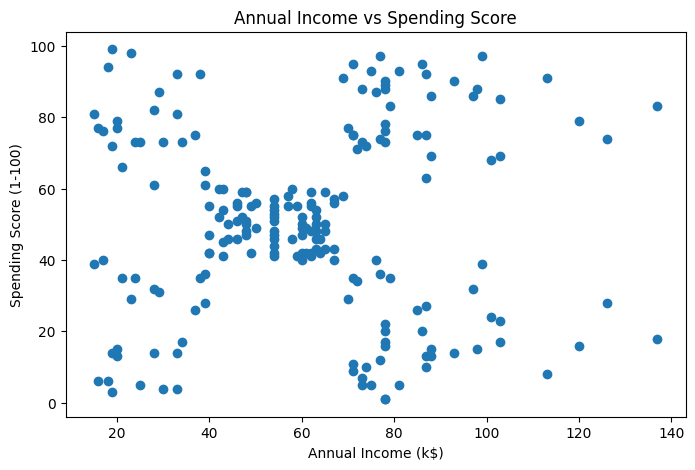

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

From the scatter plot, around 5 customer groups can be observed based on income and spending patterns.

6.2

In [62]:
from sklearn.cluster import KMeans

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Mean Annual Income", "Mean Spending Score"]
)

centroids.index.name = "Cluster"

print("Cluster Centroids")
print(centroids)


Cluster Centroids
         Mean Annual Income  Mean Spending Score
Cluster                                         
0                 55.296296            49.518519
1                 86.538462            82.128205
2                 25.727273            79.363636
3                 88.200000            17.114286
4                 26.304348            20.913043


In [63]:
cluster_summary = df.groupby("Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Mean_Annual_Income=("Annual Income (k$)", "mean"),
    Mean_Spending_Score=("Spending Score (1-100)", "mean")
)

print(cluster_summary)

         Customer_Count  Mean_Annual_Income  Mean_Spending_Score
Cluster                                                         
0                    81           55.296296            49.518519
1                    39           86.538462            82.128205
2                    22           25.727273            79.363636
3                    35           88.200000            17.114286
4                    23           26.304348            20.913043


7.1

In [64]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


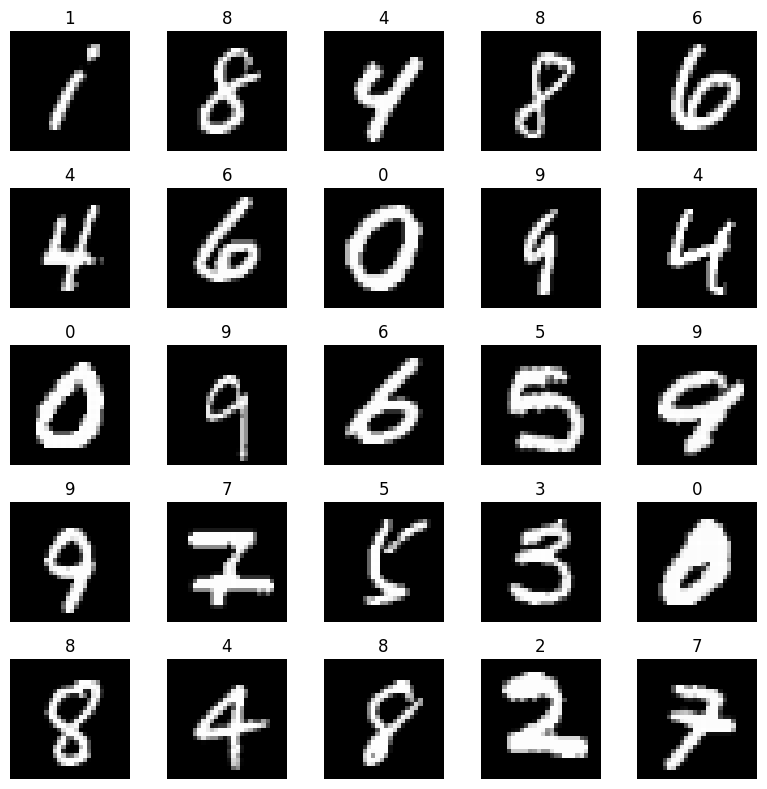

In [65]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for ax in axes.flat:
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx], cmap="gray")
    ax.set_title(y_train[idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

7.2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9210 - loss: 0.2689 - val_accuracy: 0.9563 - val_loss: 0.1522
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9655 - loss: 0.1134 - val_accuracy: 0.9681 - val_loss: 0.1109
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9761 - loss: 0.0782 - val_accuracy: 0.9702 - val_loss: 0.0976
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9811 - loss: 0.0588 - val_accuracy: 0.9706 - val_loss: 0.1015
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9851 - loss: 0.0470 - val_accuracy: 0.9729 - val_loss: 0.0931
Epoch 6/15
  39/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9919 - loss: 0.0408

The model contains 109,386 trainable parameters

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()